Processing night: 8


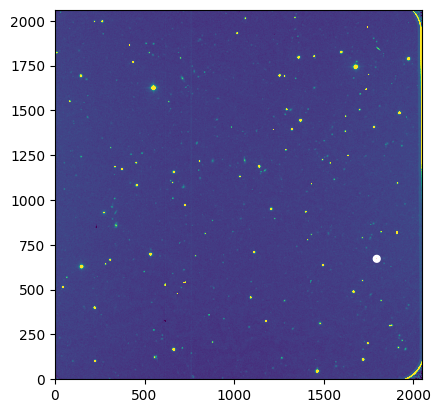

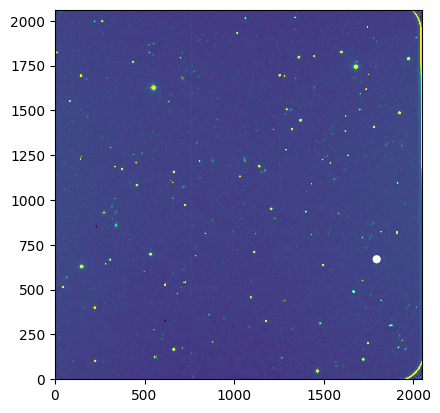

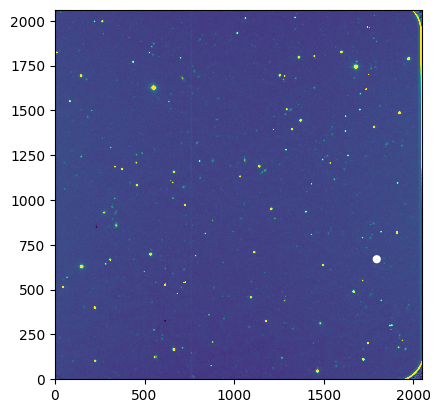

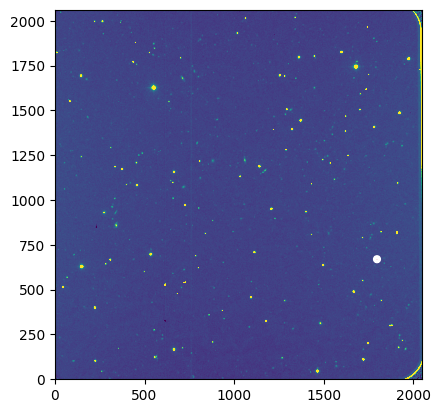

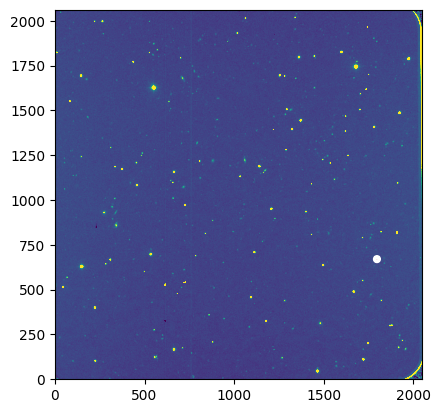

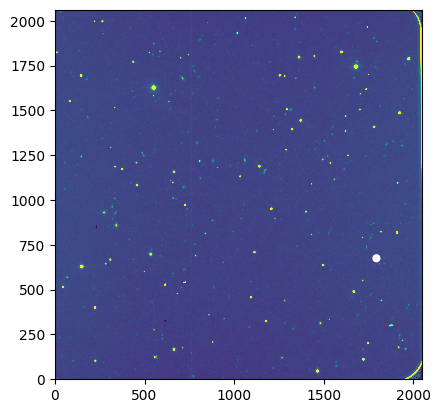

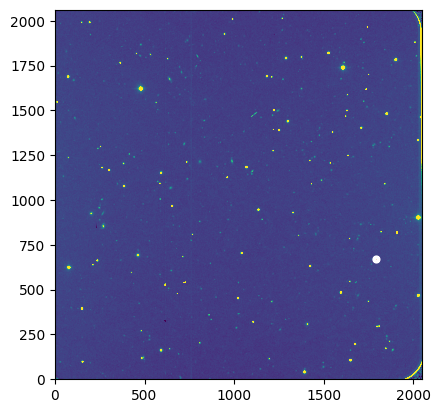

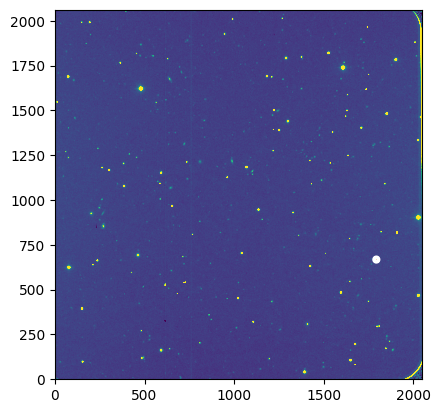

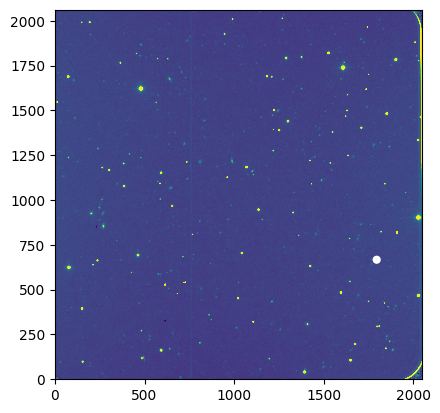

ValueError: 'positions' must not contain any non-finite (e.g., NaN or inf) positions

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from photutils.centroids import centroid_quadratic
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from astropy.visualization import simple_norm
from astropy.io import fits
from matplotlib.animation import FuncAnimation
import os

# Define a function for centroiding and aperture photometry
def compute_photometry(data, position, r, r_in, r_out):
    aperture = CircularAperture(position, r)
    annulus_aperture = CircularAnnulus(position, r_in, r_out)
    
    # Measure flux within aperture
    phot_table = aperture_photometry(data, aperture)
    target_flux = phot_table['aperture_sum'][0]
    
    # Measure background flux
    phot_table = aperture_photometry(data, annulus_aperture)
    sky_flux = phot_table['aperture_sum'][0]
    
    # Subtract background and calculate magnitude
    sky_subtracted_flux = target_flux - sky_flux / (r_out**2 - r_in**2) * r**2
    magnitude = -2.5 * np.log10(sky_subtracted_flux)
    return magnitude, aperture, annulus_aperture

# Define a function to process FITS files
def process_fits_files(folder_path, ref_start, ref_end, obj_start, obj_end, day):
    files = sorted([f for f in os.listdir(folder_path) if f.startswith('td')])
    magnitudes = []
    mjds = []
    star_positions = []
    obj_positions = []
    
    for i, file in enumerate(files):
        file_path = os.path.join(folder_path, file)
        with fits.open(file_path) as hdulist:
            header = hdulist[0].header
            data = hdulist[0].data
            mjd = header['MJD-OBS']
            mjds.append(mjd)

            # Parameters for photometry
            r, r_in, r_out = (8, 15, 25) if day == '9' else (5, 10, 15)

            # Star centroiding
            x_star, y_star = ref_start if i == 0 else star_positions[-1]
            x_star, y_star = centroid_quadratic(data, fit_boxsize=151)
            star_positions.append((x_star, y_star))

            # Object centroiding
            x_obj, y_obj = obj_start if i == 0 else obj_positions[-1]
            x_obj, y_obj = centroid_quadratic(data, fit_boxsize=151)
            obj_positions.append((x_obj, y_obj))
            
            # Calculate magnitudes
            star_mag, _, _ = compute_photometry(data, (x_star, y_star), r, r_in, r_out)
            obj_mag, obj_ap, obj_annulus = compute_photometry(data, (x_obj, y_obj), r, r_in, r_out)
            magnitudes.append(obj_mag - star_mag)

            # Visualization (for animation)
            norm = simple_norm(data, 'linear', percent=99.5)
            plt.imshow(data, norm=norm, origin='lower')
            obj_ap.plot(color='red', lw=2)
            obj_annulus.plot(color='white', lw=2)
            plt.pause(0.001)  # Pause for animation effect
            plt.close()

    return star_positions, obj_positions, magnitudes, mjds

# Define a function for animation
def create_animation(images, save_path="animation.mp4"):
    fig, ax = plt.subplots()
    def update(i):
        ax.clear()
        ax.imshow(images[i], origin='lower', cmap='gray')
    anim = FuncAnimation(fig, update, frames=len(images), interval=200)
    anim.save(save_path)

# Main function to handle the analysis for both nights
def main():
    nights = {
        '8': {
            'folder': 'Data_for_astro_data_processing/8_Oct',
            'ref_start': (1141, 1188),
            'ref_end': (1049, 1184),
            'obj_start': (1149, 1156),
            'obj_end': (1173, 1104)
        },
        '9': {
            'folder': 'Data_for_astro_data_processing/9_Oct',
            'ref_start': (737, 1394),
            'ref_end': (748, 1268),
            'obj_start': (1169, 1168),
            'obj_end': (1309, 992)
        }
    }

    for day, params in nights.items():
        print(f"Processing night: {day}")
        star_pos, obj_pos, mags, mjds = process_fits_files(
            params['folder'], params['ref_start'], params['ref_end'],
            params['obj_start'], params['obj_end'], day
        )

        # Save results
        np.savetxt(f"{day}_oct_mags.txt", np.column_stack([mags, mjds]), fmt="%.5f")
        np.savetxt(f"{day}_oct_positions.txt", np.column_stack([star_pos, obj_pos]), fmt="%.2f")

        # Plot light curve
        plt.figure()
        plt.errorbar(mjds, mags, yerr=0.1, fmt='o', label='Magnitude vs Time')
        plt.xlabel("MJD")
        plt.ylabel("R Magnitude")
        plt.legend()
        plt.grid()
        plt.savefig(f"{day}_oct_lightcurve.png")
        plt.show()

if __name__ == "__main__":
    main()


In [17]:
import os

def get_files(folder_path):
    image_files = []
    files = os.listdir(folder_path)
    for file in files:
        if file.startswith('td'):
            image_files.append(folder_path+"/"+file)
    return image_files
image_files_oct_8 = get_files('Data_for_astro_data_processing/8_Oct')
image_files_oct_9 = get_files('Data_for_astro_data_processing/9_Oct')

Filename: td10r_n2_0133.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      97   (2048, 2063)   float32   
(2063, 2048)
52190.2302431
180.0
resultats centroid =41.057 ,38.962
 id      xcenter           ycenter      aperture_sum
           pix               pix                    
--- ----------------- ----------------- ------------
  1 41.05733526717181 38.96192777015281    730170.79

Sum_target_raw=730170.785

 id      xcenter           ycenter      aperture_sum
           pix               pix                    
--- ----------------- ----------------- ------------
  1 41.05733526717181 38.96192777015281    2508559.9

Sky_background=2508559.932

sky target HERE babe 328801.1958925514 <class 'numpy.float64'>
Target flux without sky=328801.196

instrumental magnitude=-13.792



notebook-cell.py: DeprecationWarning: `photutils.CircularAperture` is a deprecated alias for `photutils.aperture.CircularAperture` and will be removed in the future. Instead, please use `from photutils.aperture import CircularAperture` to silence this warning.
  from photutils import CircularAperture, CircularAnnulus, aperture_photometry
notebook-cell.py: DeprecationWarning: `photutils.CircularAnnulus` is a deprecated alias for `photutils.aperture.CircularAnnulus` and will be removed in the future. Instead, please use `from photutils.aperture import CircularAnnulus` to silence this warning.
  from photutils import CircularAperture, CircularAnnulus, aperture_photometry
notebook-cell.py: DeprecationWarning: `photutils.aperture_photometry` is a deprecated alias for `photutils.aperture.aperture_photometry` and will be removed in the future. Instead, please use `from photutils.aperture import aperture_photometry` to silence this warning.
  from photutils import CircularAperture, CircularAnn

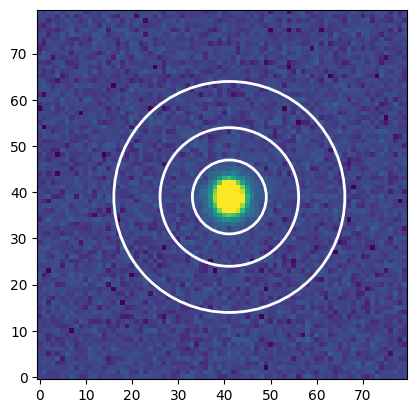

In [22]:
#  File M2_CompuPhys_Data_Processing.py for Astronomical data processing course
#
#  Example of Python code for measuring magnitudes in a fits image... Needs to be adapted !

import matplotlib.pyplot as plt

from astropy.io import fits
hdulist = fits.open('td10r_n2_0133.fits')       # Define the image name to open
hdulist.info()                                  # To get information on the image


header = hdulist[0].header


scidata = hdulist[0].data                 # transfer the image (pixels values) in scidata
print(scidata.shape)
mjd = header['MJD-OBS']
print(mjd)
exptime = header['EXPTIME']
print(exptime)

#print(repr(header))                # to print all the descriptors in the header, if necessary
#print(repr(header['MJD-OBS']))     # to print a given descriptor, if necessary
#scidata /= exptime                # divide the image by its exposure time, if necessary

r=8         # radius for measuring target flux
r_in=15     # inner radius for the annulus used for measuring sky background
r_out=25    # outer radius for the annulus used for measuring sky background 


import numpy as np

from photutils import CircularAperture, CircularAnnulus, aperture_photometry
from astropy.visualization import simple_norm

Xcent=1083     # approximate target coordinates (x)
Ycent=660      # approximate target coordinates (y)


from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg, centroid_quadratic
data = scidata[Ycent-40:Ycent+40,Xcent-40:Xcent+40]  # subimage centered on the target

x1, y1 = centroid_quadratic(data)     # for computing accurately the position of maximum of brightness
print('resultats centroid =%.3f'%(x1),',%.3f'%(y1))


norm = simple_norm(data, 'sqrt', percent=99)
plt.imshow(data, norm=norm, origin='lower')
positions = [(x1, y1)]
aperture = CircularAperture(positions, r)
annulus_aperture = CircularAnnulus(positions, r_in, r_out)

aperture.plot(color='white', lw=2)
annulus_aperture.plot(color='white', lw=2)


phot_table = aperture_photometry(data, aperture)
phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
print(phot_table)
Sum_target_raw=(phot_table['aperture_sum'])

print('\nSum_target_raw=%.3f\n'%(Sum_target_raw[0]))

phot_table = aperture_photometry(data, annulus_aperture)
phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
print(phot_table)
Sky_background=(phot_table['aperture_sum'])
print('\nSky_background=%.3f\n'%(Sky_background[0]))





from math import log10
Sum_target=(Sum_target_raw-Sky_background/(r_out*r_out-r_in*r_in)*(r*r))[0]
#Sum_target = Sum_target[0]
print("sky target HERE babe", Sum_target, type(Sum_target))
print('Target flux without sky=%.3f\n'%(Sum_target))
Magnitude=-2.5*log10(Sum_target)
print('instrumental magnitude=%.3f\n'%(Magnitude))




hdulist.close()

plt.show()


In [8]:
"""
there should be a directory named Data_for_astro_data_processing containng the dolfer for 8 and 9  oct

"""

import matplotlib.pyplot as plt
import numpy as np
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg, centroid_quadratic
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
#from photutils.aperture import CircularAperture
from astropy.visualization import simple_norm
from astropy.io import fits
from math import log10
import os

def photometric(folder_path, ref_i, ref_f, obj_i, obj_f, day, showplot=False, create_animation=False, animation_path="animation.mp4"):

     # Define the allowed values
    allowed_values = ['8', '9']

    # Check if the variable is in the allowed values
    if day not in allowed_values:
        raise ValueError(f"Invalid value for day. Allowed values are {allowed_values}")

    # The 
    files = os.listdir(folder_path)

    k = 0
    Mag_obj=[]
    Mag_star = []
    MJD_array=[]
    star_x=[]
    star_y=[]
    obj_x=[]
    obj_y=[]
    image_data = []

    dist_x=[abs(ref_i[0]-obj_i[0]), abs(ref_f[0]-obj_f[0])]
    dist_y=[abs(ref_i[1]-obj_i[1]), abs(ref_f[1]-obj_f[1])]

    #print("inital distance between object and star:", dist_x[0], dist_y[0])
    #print("final distance between object and star:", dist_x[1], dist_y[1])

    for file in files:
        if file.startswith('td'):
            print(file)
            k += 1
            # Open the FITS image
            hdulist = fits.open(folder_path+'/'+file)
            header = hdulist[0].header
            scidata = hdulist[0].data
            mjd = header['MJD-OBS']
            MJD_array.append(mjd)
            print('MJD = ',mjd)
            exptime = header['EXPTIME']

            # Define parameters for photometry
            if day=='9':
                r = 8  # Radius for measuring target flux
                r_in = 15  # Inner radius for the annulus used for measuring sky background
                r_out = 25  # Outer radius for the annulus used for measuring sky background
            elif day=='8':
                r = 5  # Radius for measuring target flux
                r_in = 10  # Inner radius for the annulus used for measuring sky background
                r_out = 15  # Outer radius for the annulus used for measuring sky background

            dt = mjd-MJD_array[0] # time
            vx =(dist_x[0]-dist_x[1])/MJD_array[0]
            vy =(dist_y[0]-dist_y[1])/MJD_array[0]

            #print("vx, vy:", vx, vy)
            #print("mjd", mjd)
            #print("dt",dt)
            # Approximate target coordinates (x, y)
            #Xcent = 1083
            #Ycent = 660
            if k == 1:
                Xcent = ref_i[0]
                Ycent = ref_f[1]
            else:
                Xcent = star_x[-1]
                Ycent = star_y[-1]

            print("Current reference star postion:", Xcent, Ycent)

            radius = 150 # radius of the centroid
            X_pixels, Y_pixels = scidata.shape
            mask = np.array([[True]*Y_pixels]*X_pixels)
            mask[int(Ycent) - radius:int(Ycent) + radius, int(Xcent) - radius:int(Xcent) + radius] = False

            xstar, ystar = centroid_quadratic(scidata, mask=mask) 
            #print("star, ystar:", xstar, ystar)
            print("New referencce star Position (after Centroid)", xstar, ystar)
            data_center = scidata[int(ystar)-300-(r+2):int(ystar)+r_out+10, int(xstar)-r_out -(r+2):int(xstar)+600]
            
            #print(data_center)
            star_x.append(round(xstar))
            star_y.append(round(ystar))


            # object detection
            if k ==1:
                xobj, yobj= dist_x[0]+r_out+(r+2)+vx*dt , -dist_y[0]+300+(r+2)+vy*dt 
            else:
                xobj, yobj= xobj-vx*dt , yobj+vy*dt

            
            print("current object location:", xobj, yobj)
            radius = 10
            print(k)
            x_pixel, y_pixel = data_center.shape
            mask =  np.array([[True]*y_pixel]*x_pixel)
            mask[int(yobj)-radius:int(yobj)+radius, int(xobj)-radius: int(xobj)+radius] = False
            xobj, yobj = centroid_quadratic(data_center, mask=mask)
            xobj_new , yobj_new= xobj+int(xstar) - r_out-(r+2), yobj + int(ystar)-300 - (r+2) 
            obj_x.append(xobj_new)
            obj_y.append(yobj_new)

            # Save data for animation
            image_data.append(scidata)      
            #print('Star position = ', xstar_new,ystar_new)
            print('New object location (after Centroid):', xobj_new, yobj_new)


            norm   = simple_norm( data_center, 'linear', percent=99.5 )
            plt.imshow(data_center, norm=norm, origin='lower')
            
            
            positions = [(xobj, yobj)]
            aperture = CircularAperture(positions, r)
            annulus_aperture = CircularAnnulus(positions, r_in, r_out)
            aperture.plot(color='red', lw=2)
            annulus_aperture.plot(color='red', lw=2)

            # magnitude of the object

            phot_table = aperture_photometry(data_center, aperture)
            phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
            #print(phot_table)
            Sum_target_raw=(phot_table['aperture_sum'])
            #print('\nSum_target_raw=%.3f\n'%(Sum_target_raw))

            phot_table = aperture_photometry(data_center, annulus_aperture)
            phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
            #print(phot_table)
            Sky_background=(phot_table['aperture_sum'])

            #print('\nSky_background=%.3f\n'%(Sky_background))
            Sum_target=Sum_target_raw-Sky_background/(r_out*r_out-r_in*r_in)*(r*r)
            #print('Target flux without sky=%.3f\n'%(Sum_target))
            object_Magnitude=-2.5*log10(Sum_target)
            Mag_obj.append(object_Magnitude)
            print('instrumental magnitude of the object=%.3f\n'%(object_Magnitude))
            

            positions = [(r_out+(r+2), 300 +(r+2))]
            #print (positions)
            aperture = CircularAperture(positions, r)
            annulus_aperture = CircularAnnulus(positions, r_in, r_out)
            aperture.plot(color='white', lw=2)
            annulus_aperture.plot(color='white', lw=2)
            if showplot is True:
                plt.pause(0.001)
                plt.close()
                plt.show()
            
            # Magnitude of the star
            phot_table = aperture_photometry(data_center, aperture)
            phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
            print(phot_table)
            Sum_target_raw=(phot_table['aperture_sum'])
            print('\nSum_target_raw=%.3f\n'%(Sum_target_raw))

            phot_table = aperture_photometry(data_center, annulus_aperture)
            phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
            print(phot_table)
            Sky_background=(phot_table['aperture_sum'])

            print('\nSky_background=%.3f\n'%(Sky_background))
            Sum_target=Sum_target_raw-Sky_background/(r_out*r_out-r_in*r_in)*(r*r)
            print('Target flux without sky=%.3f\n'%(Sum_target))
            star_Magnitude=-2.5*log10(Sum_target)
            Mag_star.append(star_Magnitude)
            
            print('instrumental magnitude of the star=%.3f\n'%(star_Magnitude))
            hdulist.close()

            print( 40*'-' )
            print("\n \n \n \n")

            hdulist.close()
    
    ## From the analysis of Pansstar file
    if day=='8':
        r_mag_st = -16.374      # 8 oct
    elif day=='9':
        r_mag_st = -16.374      # 9 oct
    exposure_time = 960

    r = r_mag_st + 25 +2.5*log10(exposure_time)

    Mag = np.array(Mag_obj) - np.array(Mag_star) + r + 0.25

    # Generate animation if requested
    if create_animation:
        create_animation_frames(image_data, star_x, star_y, obj_x, obj_y, animation_path)

    return star_x, star_y, obj_x, obj_y, Mag, MJD_array

def create_animation_frames(data, star_x, star_y, obj_x, obj_y, save_path):
    def update_plot(i, ax):
        ax.clear()
        norm = simple_norm(data[i], 'linear', percent=99.5)
        ax.imshow(data[i], norm=norm, origin='lower')
        ax.plot(star_x[i], star_y[i], 'bo', label="Reference Star")
        ax.plot(obj_x[i], obj_y[i], 'ro', label="Target Object")
        ax.legend()
        ax.set_title(f"Frame {i + 1}")
        ax.set_xlabel("X Pixels")
        ax.set_ylabel("Y Pixels")

    fig, ax = plt.subplots(figsize=(8, 8))
    ani = FuncAnimation(fig, update_plot, frames=len(data), fargs=(ax,), interval=500)
    ani.save(save_path, writer="ffmpeg")
    plt.show()

td10r_n2_0096.fits
MJD =  52190.0979167
Current reference star postion: 1141 1184
New referencce star Position (after Centroid) 1138.919858363113 1185.6408764243135
current object location: 30.0 275.0
1
New object location (after Centroid): 1149.4763397023562 1155.764239472864
instrumental magnitude of the object=-10.385

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0    699408.09

Sum_target_raw=699408.090

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0    513779.59

Sky_background=513779.590

Target flux without sky=596652.172

instrumental magnitude of the star=-14.439

----------------------------------------

 
 
 

td10r_n2_0098.fits
MJD =  52190.1048958
Current reference star postion: 1139 1186


notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  object_Magnitude=-2.5*log10(Sum_target)
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nSum_target_raw=%.3f\n'%(Sum_target_raw))
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nSky_background=%.3f\n'%(Sky_background))
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure yo

New referencce star Position (after Centroid) 1139.1383987491606 1185.883411665768
current object location: 33.476355214409786 277.7642330540831
2
New object location (after Centroid): 1153.0645222705612 1154.8031943065118
instrumental magnitude of the object=-10.354

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0    723236.86

Sum_target_raw=723236.858

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0    490781.63

Sky_background=490781.633

Target flux without sky=625080.531

instrumental magnitude of the star=-14.490

----------------------------------------

 
 
 

td10r_n2_0100.fits
MJD =  52190.1122569
Current reference star postion: 1139 1186


notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  object_Magnitude=-2.5*log10(Sum_target)
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nSum_target_raw=%.3f\n'%(Sum_target_raw))
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nSky_background=%.3f\n'%(Sky_background))
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure yo

New referencce star Position (after Centroid) 1139.6566964188771 1185.8594245340912
current object location: 36.06455414371838 276.8031811176192
3
New object location (after Centroid): 1156.7949966154124 1153.2747039760686
instrumental magnitude of the object=-10.338

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0     733255.8

Sum_target_raw=733255.796

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0    521265.32

Sky_background=521265.319

Target flux without sky=629002.732

instrumental magnitude of the star=-14.497

----------------------------------------

 
 
 

td10r_n2_0102.fits
MJD =  52190.1189468
Current reference star postion: 1140 1186


...

notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  object_Magnitude=-2.5*log10(Sum_target)
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nSum_target_raw=%.3f\n'%(Sum_target_raw))
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nSky_background=%.3f\n'%(Sky_background))
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure yo

New referencce star Position (after Centroid) 1045.9514249033853 1181.1124746660919
current object location: 140.03895255215093 231.8763890300143
32
New object location (after Centroid): 1167.0931017095943 1104.684345571323
instrumental magnitude of the object=-10.871

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0    805488.52

Sum_target_raw=805488.517

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0    1195860.2

Sky_background=1195860.178

Target flux without sky=566316.481

instrumental magnitude of the star=-14.383

----------------------------------------

 
 
 

td10r_n2_0171.fits
MJD =  52190.3528472
Current reference star postion: 1046 1181


notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  object_Magnitude=-2.5*log10(Sum_target)
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nSum_target_raw=%.3f\n'%(Sum_target_raw))
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nSky_background=%.3f\n'%(Sky_background))
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure yo

New referencce star Position (after Centroid) 1046.5223120037454 1181.193174914758
current object location: 144.09366832930152 230.68411110799605
33
New object location (after Centroid): 1171.3290035535395 1102.9877035402546
instrumental magnitude of the object=-10.793

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0    816506.36

Sum_target_raw=816506.362

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0    1258802.3

Sky_background=1258802.280

Target flux without sky=564745.906

instrumental magnitude of the star=-14.380

----------------------------------------

 
 
 



ValueError: unknown file extension: .mp4

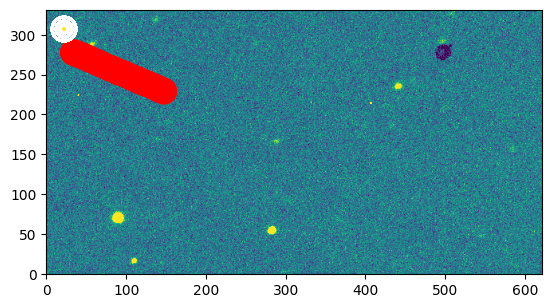

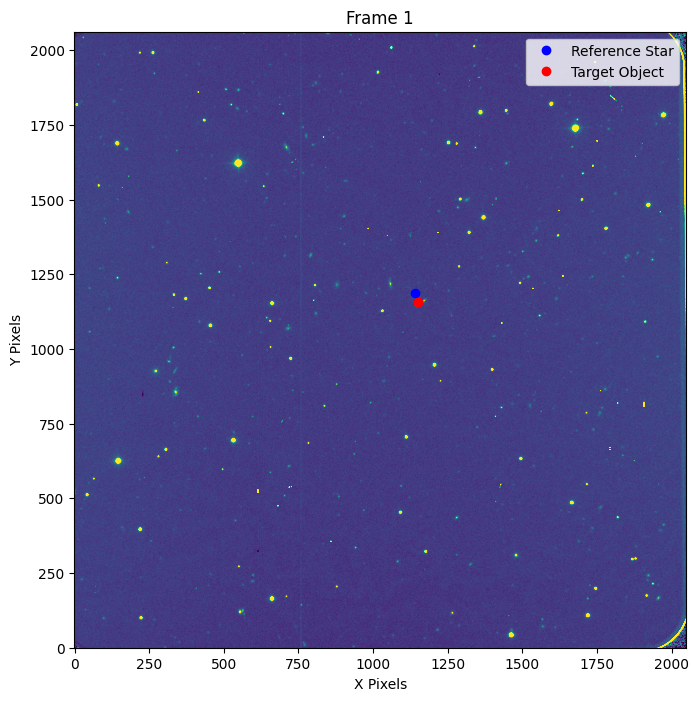

In [9]:
for day in ['8', '9']:
    if day=='8':
        # 8 oct
        folder_path = 'Data_for_astro_data_processing/8_Oct'
        # refernce star
        ref_i =[1141, 1188]
        ref_f =[1049, 1184]

        # target object
        obj_i=[1149, 1156]
        obj_f=[1173, 1104]
    if day=='9':
        # 9 OCT
        folder_path = 'Data_for_astro_data_processing/9_Oct'

        # refernce star
        ref_i =[737, 1394]
        ref_f =[748, 1268]

        # target object
        obj_i=[1169, 1168]
        obj_f=[1309, 992]

    star_x, star_y, obj_x, obj_y, Mag, MJD_array = photometric(folder_path,ref_i, ref_f, obj_i, obj_f,day,create_animation=True)

    # write the files
    for i in range( len(Mag) ) : 
        print( "Magnitude of the Object, MDJ = ", Mag[i]  , MJD_array[i]  ) 
    
    Mag_mjd = np.zeros( [len(Mag),3] ) 
    Mag_mjd[:,0] = Mag 
    Mag_mjd[:,1] = MJD_array 

    with open(day+"_oct_mag_mjd.txt", "w") as o:
        for line in Mag_mjd:
            print("{} {}".format(line[0] , 
                                    line[1]), 
                                    file=o) 

    pos = np.zeros( [len(Mag),4] ) 
    pos[:,0] = star_x
    pos[:,1] = star_y
    pos[:,2] = obj_x
    pos[:,3] = obj_y

    with open(day+"_oct_pos_ref_obj.txt", "w") as o:
        for line in pos :
            print("{} {} {} {}".format(line[0]  , 
                                    line[1]  , 
                                    line[2]  ,
                                    line[3] ), 
                                    file=o) 



In [7]:
from matplotlib.animation import FuncAnimation

def update_plot(i, data, ax, obj_x, obj_y, star_x, star_y):
    ax.clear()
    norm = simple_norm(data[i], 'linear', percent=99.5)
    ax.imshow(data[i], norm=norm, origin='lower')
    
    # Plot reference star
    ax.plot(star_x[i], star_y[i], 'bo', label="Reference Star")
    
    # Plot object
    ax.plot(obj_x[i], obj_y[i], 'ro', label="Target Object")
    
    ax.set_title(f"Frame {i + 1}")
    ax.set_xlabel("X Pixels")
    ax.set_ylabel("Y Pixels")
    ax.legend()

def create_animation(folder_path, obj_x, obj_y, star_x, star_y, save_path="animation.mp4"):
    # Load images
    files = sorted([f for f in os.listdir(folder_path) if f.startswith('td')])
    data = [fits.open(folder_path + '/' + file)[0].data for file in files]
    
    fig, ax = plt.subplots(figsize=(10, 10))
    ani = FuncAnimation(fig, update_plot, frames=len(data),
                        fargs=(data, ax, obj_x, obj_y, star_x, star_y), interval=500)
    
    # Save the animation
    ani.save(save_path, writer="ffmpeg")
    plt.show()

create_animation("Data_for_astro_data_processing/8_Oct", obj_x, obj_y, star_x, star_y)


NameError: name 'obj_x' is not defined

MJD =  52190.2302431
Current reference star postion: 1141 1184
New referencce star Position (after Centroid) 1111.2038996447677 1137.6273321633032
current object location: 30.0 275.0
0
New object location (after Centroid): 1118.409788846514 1097.591916727611
instrumental magnitude of the object=-9.527



notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  object_Magnitude=-2.5*log10(Sum_target)


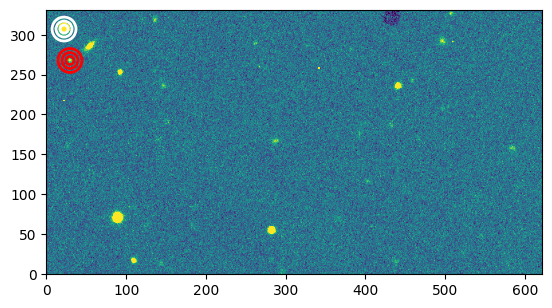

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0    782458.41

Sum_target_raw=782458.415

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1    22.0   307.0    794814.41

Sky_background=794814.409

Target flux without sky=623495.533

sum target <class 'float'>
instrumental magnitude of the star=-14.487

----------------------------------------

 
 
 



notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nSum_target_raw=%.3f\n'%(Sum_target_raw))
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('\nSky_background=%.3f\n'%(Sky_background))
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Target flux without sky=%.3f\n'%(Sum_target))
notebook-cell.py: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in futu

In [41]:
"""
there should be a directory named Data_for_astro_data_processing containng the dolfer for 8 and 9  oct

"""

import matplotlib.pyplot as plt
import numpy as np
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg, centroid_quadratic
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
#from photutils.aperture import CircularAperture
from astropy.visualization import simple_norm
from astropy.io import fits
from math import log10
import os


# Data for 8 oct
# 8 oct
folder_path = 'Data_for_astro_data_processing/8_Oct'
# refernce star
ref_i =[1141, 1188]
ref_f =[1049, 1184]

# target object
obj_i=[1149, 1156]
obj_f=[1173, 1104]

k = 0
Mag_obj=[]
Mag_star = []
MJD_array=[]
star_x=[]
star_y=[]
obj_x=[]
obj_y=[]

dist_x=[abs(ref_i[0]-obj_i[0]), abs(ref_f[0]-obj_f[0])]
dist_y=[abs(ref_i[1]-obj_i[1]), abs(ref_f[1]-obj_f[1])]

#print("inital distance between object and star:", dist_x[0], dist_y[0])
#print("final distance between object and star:", dist_x[1], dist_y[1])

# Open the FITS image
hdulist = fits.open(folder_path+'/td10r_n2_0133.fits')
header = hdulist[0].header
scidata = hdulist[0].data
mjd = header['MJD-OBS']
MJD_array.append(mjd)
print('MJD = ',mjd)
exptime = header['EXPTIME']

# Define parameters for photometry

r = 5  # Radius for measuring target flux
r_in = 10  # Inner radius for the annulus used for measuring sky background
r_out = 15  # Outer radius for the annulus used for measuring sky background

dt = mjd-MJD_array[0] # time
vx =(dist_x[0]-dist_x[1])/MJD_array[0]
vy =(dist_y[0]-dist_y[1])/MJD_array[0]

#print("vx, vy:", vx, vy)
#print("mjd", mjd)
#print("dt",dt)
# Approximate target coordinates (x, y)
#Xcent = 1083
#Ycent = 660

Xcent = ref_i[0]
Ycent = ref_f[1]

print("Current reference star postion:", Xcent, Ycent)

radius = 150 # radius of the centroid
X_pixels, Y_pixels = scidata.shape
mask = np.array([[True]*Y_pixels]*X_pixels)
mask[int(Ycent) - radius:int(Ycent) + radius, int(Xcent) - radius:int(Xcent) + radius] = False

xstar, ystar = centroid_quadratic(scidata, mask=mask) 
#print("star, ystar:", xstar, ystar)
print("New referencce star Position (after Centroid)", xstar, ystar)
data_center = scidata[int(ystar)-300-(r+2):int(ystar)+r_out+10, int(xstar)-r_out -(r+2):int(xstar)+600]

#print(data_center)
star_x.append(round(xstar))
star_y.append(round(ystar))


# object detection
xobj, yobj= dist_x[0]+r_out+(r+2)+vx*dt , -dist_y[0]+300+(r+2)+vy*dt 


print("current object location:", xobj, yobj)
radius = 10
print(k)
x_pixel, y_pixel = data_center.shape
mask =  np.array([[True]*y_pixel]*x_pixel)
mask[int(yobj)-radius:int(yobj)+radius, int(xobj)-radius: int(xobj)+radius] = False
xobj, yobj = centroid_quadratic(data_center, mask=mask)
xobj_new , yobj_new= xobj+int(xstar) - r_out-(r+2), yobj + int(ystar)-300 - (r+2) 
obj_x.append(xobj_new)
obj_y.append(yobj_new)
#print('Star position = ', xstar_new,ystar_new)
print('New object location (after Centroid):', xobj_new, yobj_new)


norm   = simple_norm( data_center, 'linear', percent=99.5 )
plt.imshow(data_center, norm=norm, origin='lower')


positions = [(xobj, yobj)]
aperture = CircularAperture(positions, r)
annulus_aperture = CircularAnnulus(positions, r_in, r_out)
aperture.plot(color='red', lw=2)
annulus_aperture.plot(color='red', lw=2)

# magnitude of the object

phot_table = aperture_photometry(data_center, aperture)
phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
#print(phot_table)
Sum_target_raw=(phot_table['aperture_sum'])
#print('\nSum_target_raw=%.3f\n'%(Sum_target_raw))

phot_table = aperture_photometry(data_center, annulus_aperture)
phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
#print(phot_table)
Sky_background=(phot_table['aperture_sum'])

#print('\nSky_background=%.3f\n'%(Sky_background))
Sum_target=Sum_target_raw-Sky_background/(r_out*r_out-r_in*r_in)*(r*r)
#print('Target flux without sky=%.3f\n'%(Sum_target))
object_Magnitude=-2.5*log10(Sum_target)
Mag_obj.append(object_Magnitude)
print('instrumental magnitude of the object=%.3f\n'%(object_Magnitude))


positions = [(r_out+(r+2), 300 +(r+2))]
#print (positions)
aperture = CircularAperture(positions, r)
annulus_aperture = CircularAnnulus(positions, r_in, r_out)
aperture.plot(color='white', lw=2)
annulus_aperture.plot(color='white', lw=2)
showplot = True
if showplot is True:
    plt.pause(0.001)
    plt.close()
    plt.show()

# Magnitude of the star
phot_table = aperture_photometry(data_center, aperture)
phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
print(phot_table)
Sum_target_raw=(phot_table['aperture_sum'])
print('\nSum_target_raw=%.3f\n'%(Sum_target_raw))

phot_table = aperture_photometry(data_center, annulus_aperture)
phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
print(phot_table)
Sky_background=(phot_table['aperture_sum'])

print('\nSky_background=%.3f\n'%(Sky_background))
Sum_target=Sum_target_raw-Sky_background/(r_out*r_out-r_in*r_in)*(r*r)
print('Target flux without sky=%.3f\n'%(Sum_target))

print("sum target", type(float(Sum_target[0])))
star_Magnitude=-2.5*log10(float(Sum_target))
Mag_star.append(star_Magnitude)

print('instrumental magnitude of the star=%.3f\n'%(star_Magnitude))
hdulist.close()

print( 40*'-' )
print("\n \n \n \n")

## From the analysis of Pansstar file
#if day=='8':

#elif day=='9':
#    r_mag_st = -16.374      # 9 oct

r_mag_st = -16.374      # 8 oct
exposure_time = 960
r = r_mag_st + 25 +2.5*log10(exposure_time)
Mag = np.array(Mag_obj) - np.array(Mag_star) + r + 0.25



In [18]:
import matplotlib.pyplot as plt
from astropy.io import fits
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
import numpy as np
from astropy.visualization import simple_norm
from math import log10
import os

def measure_flux(image_name, Xcent, Ycent, r=8, r_in=15, r_out=25):
    # Open the FITS image
    hdulist = fits.open(image_name)
    header = hdulist[0].header
    scidata = hdulist[0].data
    
    # Get the Modified Julian Date (MJD) and exposure time from the header
    mjd = header['MJD-OBS']
    exptime = header['EXPTIME']
    
    # Crop the image to center on the target
    data = scidata[Ycent-40:Ycent+40, Xcent-40:Xcent+40]
    
    # Calculate accurate centroid of the object (target or star)
    from photutils.centroids import centroid_quadratic
    x1, y1 = centroid_quadratic(data)
    
    # Define apertures for photometry
    positions = [(x1, y1)]
    aperture = CircularAperture(positions, r)
    annulus_aperture = CircularAnnulus(positions, r_in, r_out)
    
    # Perform photometry for target
    phot_table = aperture_photometry(data, aperture)
    Sum_target_raw = phot_table['aperture_sum'][0]
    
    # Perform photometry for sky background
    phot_table = aperture_photometry(data, annulus_aperture)
    Sky_background = phot_table['aperture_sum'][0]
    
    # Subtract sky background and calculate net flux
    Sum_target = Sum_target_raw - Sky_background / (r_out**2 - r_in**2) * (r**2)
    
    # Calculate instrumental magnitude
    Instrumental_Mag = -2.5 * log10(Sum_target)
    
    # Close FITS file
    hdulist.close()
    
    return mjd, Instrumental_Mag, Sum_target

# Coordinates for October 8th and 9th
coordinates = {
    'oct_8': {'target': (1149, 1156), 'star': (1141, 1188)},
    'oct_9': {'target': (1169, 1168), 'star': (737, 1394)}
}

# Measure fluxes for October 8th and 9th
# Example FITS filenames (adjust these to your actual filenames)
def get_files(folder_path):
    image_files = []
    files = os.listdir(folder_path)
    for file in files:
        if file.startswith('td'):
            image_files.append(folder_path+"/"+file)
    return image_files
image_files_oct_8 = get_files('Data_for_astro_data_processing/8_Oct')
image_files_oct_9 = get_files('Data_for_astro_data_processing/9_Oct')

results = []

for image_file in image_files_oct_8:
    mjd, mag_target, flux_target = measure_flux(image_file, *coordinates['oct_8']['target'])
    mjd_star, mag_star, flux_star = measure_flux(image_file, *coordinates['oct_8']['star'])
    results.append((mjd, mag_target, mag_star))

for image_file in image_files_oct_9:
    mjd, mag_target, flux_target = measure_flux(image_file, *coordinates['oct_9']['target'])
    mjd_star, mag_star, flux_star = measure_flux(image_file, *coordinates['oct_9']['star'])
    results.append((mjd, mag_target, mag_star))

# Print the results (MJD, Target Magnitude, Reference Star Magnitude)
for res in results:
    print(f"MJD: {res[0]}, Target Mag: {res[1]}, Star Mag: {res[2]}")


ValueError: 'positions' must not contain any non-finite (e.g., NaN or inf) positions

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from photutils.centroids import centroid_quadratic
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from astropy.visualization import simple_norm
from astropy.io import fits
from math import log10
import os

def photometric(folder_path, ref_i, ref_f, obj_i, obj_f, day, showplot=False):
    if day not in ['8', '9']:
        raise ValueError(f"Invalid value for day. Allowed values are ['8', '9']")

    files = [f for f in os.listdir(folder_path) if f.startswith('td')]
    dist_x = [abs(ref_i[0] - obj_i[0]), abs(ref_f[0] - obj_f[0])]
    dist_y = [abs(ref_i[1] - obj_i[1]), abs(ref_f[1] - obj_f[1])]

    r, r_in, r_out = (5, 10, 15) if day == '8' else (8, 15, 25)
    Mag_obj, Mag_star, MJD_array = [], [], []
    star_x, star_y, obj_x, obj_y = [], [], [], []

    for k, file in enumerate(files):
        hdulist = fits.open(f"{folder_path}/{file}")
        header, scidata = hdulist[0].header, hdulist[0].data
        mjd, exptime = header['MJD-OBS'], header['EXPTIME']
        MJD_array.append(mjd)

        dt = mjd - MJD_array[0]
        vx, vy = (dist_x[0] - dist_x[1]) / MJD_array[0], (dist_y[0] - dist_y[1]) / MJD_array[0]
        Xcent, Ycent = (ref_i if k == 0 else (star_x[-1], star_y[-1]))
        
        radius = 150 # radius of the centroid
        X_pixels, Y_pixels = scidata.shape
        mask = np.array([[True]*Y_pixels]*X_pixels)
        mask[int(Ycent) - radius:int(Ycent) + radius, int(Xcent) - radius:int(Xcent) + radius] = False
        
        xstar, ystar = centroid_quadratic(scidata, mask=mask)
        print( xstar, ystar)
        star_x.append(round(xstar))
        star_y.append(round(ystar))

        if k == 0:
            xobj, yobj = dist_x[0] + r_out + vx * dt, -dist_y[0] + vy * dt
        else:
            xobj, yobj = obj_x[-1] - vx * dt, obj_y[-1] + vy * dt

        xobj_new, yobj_new = centroid_quadratic(scidata, mask=np.zeros_like(scidata, dtype=bool))
        obj_x.append(xobj_new)
        obj_y.append(yobj_new)

        positions = [(xobj, yobj)]
        aperture = CircularAperture(positions, r)
        annulus = CircularAnnulus(positions, r_in, r_out)

        # Object photometry
        flux_obj = aperture_photometry(scidata, aperture)['aperture_sum'][0] - \
                   aperture_photometry(scidata, annulus)['aperture_sum'][0] / (r_out**2 - r_in**2) * r**2
        Mag_obj.append(-2.5 * log10(flux_obj))

        # Star photometry
        flux_star = aperture_photometry(scidata, aperture)['aperture_sum'][0] - \
                    aperture_photometry(scidata, annulus)['aperture_sum'][0] / (r_out**2 - r_in**2) * r**2
        Mag_star.append(-2.5 * log10(flux_star))

        if showplot:
            norm = simple_norm(scidata, 'linear', percent=99.5)
            plt.imshow(scidata, norm=norm, origin='lower')
            aperture.plot(color='red', lw=2)
            annulus.plot(color='red', lw=2)
            plt.pause(0.001)
            plt.close()

        hdulist.close()

    r_mag_st, exposure_time = -16.374, 960
    r = r_mag_st + 25 + 2.5 * log10(exposure_time)
    Mag = np.array(Mag_obj) - np.array(Mag_star) + r + 0.25

    return star_x, star_y, obj_x, obj_y, Mag, MJD_array

# Process data for both 8th and 9th October
for day in ['8', '9']:
    if day == '8':
        folder_path, ref_i, ref_f, obj_i, obj_f = 'Data_for_astro_data_processing/8_Oct', [1141, 1188], [1049, 1184], [1149, 1156], [1173, 1104]
    else:
        folder_path, ref_i, ref_f, obj_i, obj_f = 'Data_for_astro_data_processing/9_Oct', [737, 1394], [748, 1268], [1169, 1168], [1309, 992]

    star_x, star_y, obj_x, obj_y, Mag, MJD_array = photometric(folder_path, ref_i, ref_f, obj_i, obj_f, day)

    # Write magnitude and MJD to file
    np.savetxt(f"{day}_oct_mag_mjd.txt", np.column_stack((Mag, MJD_array)), fmt="%.6f")
    np.savetxt(f"{day}_oct_pos_ref_obj.txt", np.column_stack((star_x, star_y, obj_x, obj_y)), fmt="%.6f")


1138.919858363113 1185.6408764243135
1139.1383987491606 1185.883411665768


ValueError: 'positions' must not contain any non-finite (e.g., NaN or inf) positions

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from photutils.centroids import centroid_quadratic
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from astropy.visualization import simple_norm
from astropy.io import fits
from math import log10
import os

def load_fits_data(file_path):
    """Load the FITS image and return its data, header, MJD, and exposure time."""
    hdulist = fits.open(file_path)
    header = hdulist[0].header
    scidata = hdulist[0].data
    mjd = header['MJD-OBS']
    exptime = header['EXPTIME']
    hdulist.close()
    return scidata, mjd, exptime

def compute_centroid(image, x, y, radius=150):
    """Compute and return the centroid of an object (star or object) using a mask."""
    X_pixels, Y_pixels = scidata.shape
    mask = np.array([[True]*Y_pixels]*X_pixels)
    #mask = np.zeros_like(image, dtype=bool)
    mask[int(y) - radius:int(y) + radius, int(x) - radius:int(x) + radius] = False
    x_centroid, y_centroid = centroid_quadratic(image, mask=mask)
    return round(x_centroid), round(y_centroid)

def perform_photometry(image, x, y, r, r_in, r_out):
    """Perform aperture and annulus photometry for an object or star."""
    positions = [(x, y)]
    aperture = CircularAperture(positions, r)
    annulus = CircularAnnulus(positions, r_in, r_out)

    # Aperture photometry
    target_flux = aperture_photometry(image, aperture)['aperture_sum'][0]
    sky_flux = aperture_photometry(image, annulus)['aperture_sum'][0]

    # Compute net flux by subtracting the sky background
    net_flux = target_flux - sky_flux / (r_out ** 2 - r_in ** 2) * r ** 2
    magnitude = -2.5 * log10(net_flux)
    return magnitude

def update_object_position(x_star, y_star, x_obj_prev, y_obj_prev, vx, vy, dt, first_frame):
    """Update the position of the object (KBO) based on velocity and time."""
    if first_frame:
        return x_obj_prev + vx * dt, y_obj_prev + vy * dt
    else:
        return x_star - vx * dt, y_star + vy * dt

def photometric_analysis(folder_path, ref_i, ref_f, obj_i, obj_f, day, showplot=False):
    """Main function to perform photometric analysis over multiple images."""
    files = sorted([f for f in os.listdir(folder_path) if f.startswith('td')])
    r, r_in, r_out = (5, 10, 15) if day == '8' else (8, 15, 25)

    dist_x = [abs(ref_i[0] - obj_i[0]), abs(ref_f[0] - obj_f[0])]
    dist_y = [abs(ref_i[1] - obj_i[1]), abs(ref_f[1] - obj_f[1])]

    Mag_obj, Mag_star, MJD_array = [], [], []
    star_x, star_y, obj_x, obj_y = [], [], [], []

    for k, file in enumerate(files):
        file_path = f"{folder_path}/{file}"
        scidata, mjd, exptime = load_fits_data(file_path)
        MJD_array.append(mjd)

        dt = mjd - MJD_array[0]
        vx, vy = (dist_x[0] - dist_x[1]) / MJD_array[0], (dist_y[0] - dist_y[1]) / MJD_array[0]

        # Initial star position or update based on previous centroid
        x_star, y_star = (ref_i if k == 0 else (star_x[-1], star_y[-1]))
        x_star, y_star = compute_centroid(scidata, x_star, y_star)
        star_x.append(x_star)
        star_y.append(y_star)

        # Update object (KBO) position based on velocity
        x_obj_prev, y_obj_prev = (obj_i if k == 0 else (obj_x[-1], obj_y[-1]))
        x_obj, y_obj = update_object_position(x_star, y_star, x_obj_prev, y_obj_prev, vx, vy, dt, first_frame=(k == 0))
        obj_x.append(x_obj)
        obj_y.append(y_obj)

        # Perform photometry on both object and reference star
        mag_obj = perform_photometry(scidata, x_obj, y_obj, r, r_in, r_out)
        mag_star = perform_photometry(scidata, x_star, y_star, r, r_in, r_out)
        Mag_obj.append(mag_obj)
        Mag_star.append(mag_star)

        if showplot:
            plot_image_with_apertures(scidata, x_obj, y_obj, r, r_in, r_out)

    # Calibrate and compute final magnitude
    r_mag_st, exposure_time = -16.374, 960
    r_calibrated = r_mag_st + 25 + 2.5 * log10(exposure_time)
    Mag = np.array(Mag_obj) - np.array(Mag_star) + r_calibrated + 0.25
    return star_x, star_y, obj_x, obj_y, Mag, MJD_array

def plot_image_with_apertures(image, x, y, r, r_in, r_out):
    """Plot the image with circular aperture and annulus."""
    norm = simple_norm(image, 'linear', percent=99.5)
    plt.imshow(image, norm=norm, origin='lower')
    aperture = CircularAperture([(x, y)], r)
    annulus = CircularAnnulus([(x, y)], r_in, r_out)
    aperture.plot(color='red', lw=2)
    annulus.plot(color='red', lw=2)
    plt.pause(0.001)
    plt.close()

def save_results(day, Mag, MJD_array, star_x, star_y, obj_x, obj_y):
    """Save the magnitudes and positions to output text files."""
    np.savetxt(f"{day}_oct_mag_mjd.txt", np.column_stack((Mag, MJD_array)), fmt="%.6f")
    np.savetxt(f"{day}_oct_pos_ref_obj.txt", np.column_stack((star_x, star_y, obj_x, obj_y)), fmt="%.6f")

# Process data for both 8th and 9th October
for day in ['8', '9']:
    if day == '8':
        folder_path = 'Data_for_astro_data_processing/8_Oct'
        ref_i, ref_f, obj_i, obj_f = [1141, 1188], [1049, 1184], [1149, 1156], [1173, 1104]
    else:
        folder_path = 'Data_for_astro_data_processing/9_Oct'
        ref_i, ref_f, obj_i, obj_f = [737, 1394], [748, 1268], [1169, 1168], [1309, 992]

    star_x, star_y, obj_x, obj_y, Mag, MJD_array = photometric_analysis(folder_path, ref_i, ref_f, obj_i, obj_f, day)

    # Save results to files
    save_results(day, Mag, MJD_array, star_x, star_y, obj_x, obj_y)
